### Import Libraries
- fetch_openml → loads MNIST
- MinMaxScaler → normalizes pixel values 
- cosine_similarity → used for image retrieval
- PCA → reduces latent space to 2D
- tensorflow → builds the autoencoder

In [3]:
# Basic libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Dataset + preprocessing
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# Similarity + dimensionality reduction
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA

# Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, Model

### Load and Prepare the Dataset
- Neural networks need normalized data → improves training
- We split into train/test for evaluation

In [4]:
# Load dataset
mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)

# Normalize (scale pixel values from 0-255 → 0-1)
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

### Build Autoencoder
- Encoder → compresses 784 → 32
- Decoder → reconstructs back to 784
- sigmoid → outputs values between 0–1
- mse → measures reconstruction error

In [5]:
input_dim = 784      # 28x28 image
latent_dim = 32      # compressed representation

# Input layer
input_layer = layers.Input(shape=(input_dim,))

# -------- Encoder --------
x = layers.Dense(128, activation='relu')(input_layer)
x = layers.Dense(64, activation='relu')(x)
latent = layers.Dense(latent_dim, activation='relu')(x)

# -------- Decoder --------
x = layers.Dense(64, activation='relu')(latent)
x = layers.Dense(128, activation='relu')(x)
output_layer = layers.Dense(input_dim, activation='sigmoid')(x)

# Full model
autoencoder = Model(input_layer, output_layer)

# Encoder model (for feature extraction)
encoder = Model(input_layer, latent)

# Compile model
autoencoder.compile(optimizer='adam', loss='mse')

### Train Model
- Autoencoder learns by reconstructing input
- That’s why we use (X_train, X_train)

In [6]:
history = autoencoder.fit(
    X_train, X_train,          # input = output (important!)
    epochs=20,
    batch_size=256,
    validation_data=(X_test, X_test)
)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0682 - val_loss: 0.0400
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0322 - val_loss: 0.0271
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0247 - val_loss: 0.0228
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0217 - val_loss: 0.0205
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0196 - val_loss: 0.0188
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0183 - val_loss: 0.0177
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0172 - val_loss: 0.0167
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0163 - val_loss: 0.0159
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0156 - val_loss: 0.0153
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0149 - val_loss: 0.0146
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0143 - val_loss: 0.0142
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 

### Plot Training Loss
- If model is learning
- If overfitting is happening

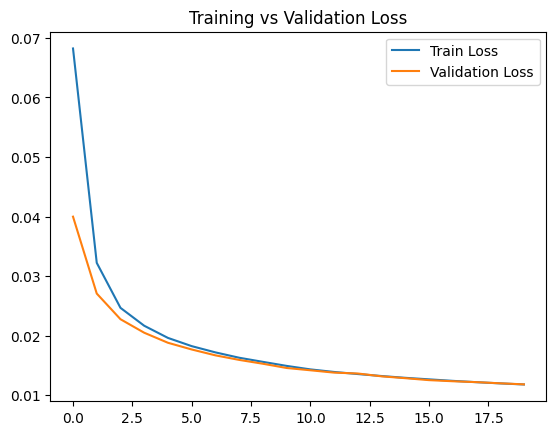

In [7]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

### Reconstruction Visualization
- Top row = original
- Bottom row = reconstructed
- Shows how well model learned

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


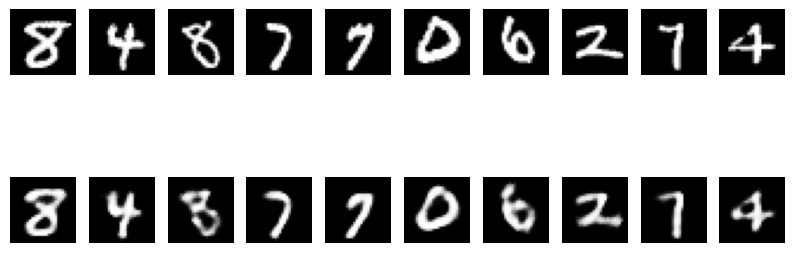

In [8]:
decoded_imgs = autoencoder.predict(X_test[:10])

plt.figure(figsize=(10, 4))

for i in range(10):
    # Original image
    plt.subplot(2, 10, i + 1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

    # Reconstructed image
    plt.subplot(2, 10, i + 11)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.axis('off')

plt.show()

### Latent Space Visualization (2D)
- Each point = one image
- Colors = digit labels
- Clusters = learned patterns

438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


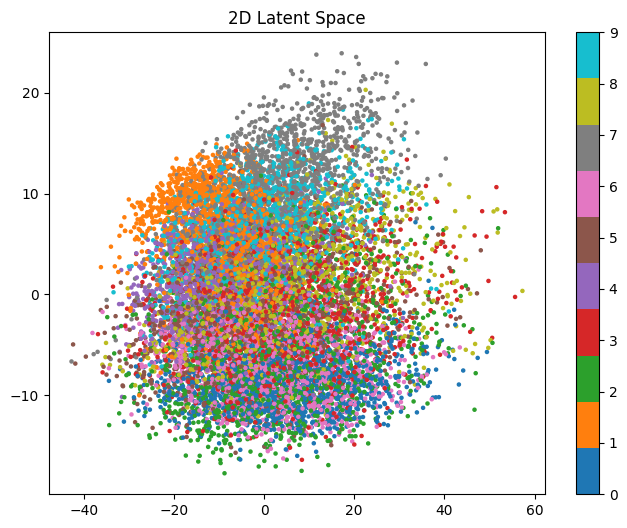

In [9]:
# Encode test data
latent_test = encoder.predict(X_test)

# Reduce to 2D
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_test)

# Plot
plt.figure(figsize=(8,6))
plt.scatter(latent_2d[:,0], latent_2d[:,1], c=y_test, cmap='tab10', s=5)
plt.colorbar()
plt.title("2D Latent Space")
plt.show()

### Image Retrieval (via Cosine Similarity)
- Converts images → feature vectors
- Compares using cosine similarity
- Retrieves most similar digits

1750/1750 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


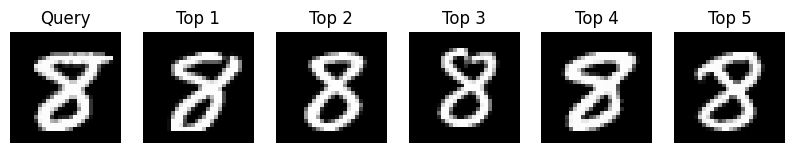

In [10]:
# Encode entire training set
latent_train = encoder.predict(X_train)

# Select query image
query = X_test[0].reshape(1, -1)

# Encode query
query_latent = encoder.predict(query)

# Compute similarity
similarities = cosine_similarity(query_latent, latent_train)

# Get top 5 similar images
top5_idx = np.argsort(similarities[0])[-5:]

# Plot results
plt.figure(figsize=(10, 3))

# Query image
plt.subplot(1, 6, 1)
plt.imshow(query.reshape(28,28), cmap='gray')
plt.title("Query")
plt.axis('off')

# Similar images
for i, idx in enumerate(top5_idx):
    plt.subplot(1, 6, i+2)
    plt.imshow(X_train[idx].reshape(28,28), cmap='gray')
    plt.title(f"Top {i+1}")
    plt.axis('off')

plt.show()

### Conclusion
This model compresses images into a latent space and reconstructs them. The latent representations are used for visualization and similarity-based retrieval using cosine similarity.